In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [139]:
df = pd.read_excel('BD_Extraccion.xlsx',sheet_name='datos', header=1)   # utilizamos la ubicacion fisica de archivo en la pc
df.head(5)

,FECHA,TURNO,ZONA,TIPO_LABOR,NIVEL,CUERPO,LABOR,VOLQUETES,PLAN_SEMANAL,PLAN_DIARIO,REALIZADO
0,2020-01-01,A,Zona Alta,Tajos,1910.0,OB6A,T-841B,NaN,2500.0,0.0,0.000000
1,2020-01-01,A,Zona Alta,Tajos,1880.0,OB6A,T-731B,6.0,1000.0,2500.0,1575.257900
2,2020-01-01,A,Zona Alta,Tajos,1880.0,OB6A,T-761E,5.0,2000.0,2500.0,2689.573857
3,2020-01-01,A,Zona Baja,Tajos,1650.0,OB1,T-001E,8.0,2500.0,2600.0,2416.588824
4,2020-01-01,A,Zona Baja,Tajos,1640.0,OB1,T-101,6.0,1500.0,2000.0,984.536187


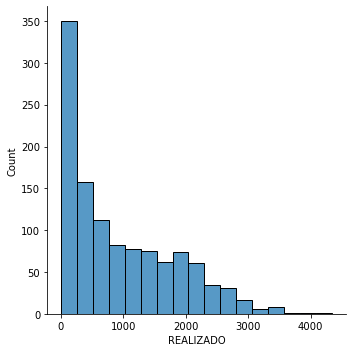

In [90]:
#Histograma de Tons realizado por Labor
sns.displot(df, x="REALIZADO")

ANALISIS DATA POR DIA, utilizamos el dataframe df1

In [140]:
# df1 = Produccion diaria
#df1 = df.groupby('FECHA').REALIZADO.sum().reset_index('FECHA')
df1 = df.groupby(['FECHA'])[('PLAN_DIARIO','REALIZADO')].sum().reset_index(['FECHA'])
df1 = df1.rename(columns={"REALIZADO": "REALIZADO_DIARIO"})

df1.head(4)

,FECHA,PLAN_DIARIO,REALIZADO_DIARIO
0,2020-01-01,18000.0,15886.833932
1,2020-01-02,18200.0,19413.263549
2,2020-01-03,20700.0,18750.939205
3,2020-01-04,20000.0,18503.015092


(array([ 3., 10., 13., 17., 12.,  5.]),
 array([12271.78403401, 14041.56442102, 15811.34480803, 17581.12519503,
        19350.90558204, 21120.68596905, 22890.46635605]),
 <BarContainer object of 6 artists>)

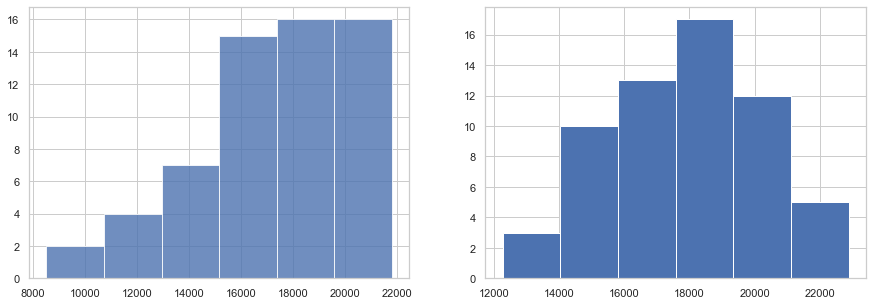

In [264]:

#plt.figure(figsize = [10, 6]) # larger figure size for subplots
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)

plt.subplot(1, 2, 1) # 1 row, 2 cols, subplot 1
plt.hist(data = df1, x = 'PLAN_DIARIO', bins = 6, alpha=0.8, label="Plan Diario")


plt.subplot(1, 2, 2) # 1 row, 2 cols, subplot 2
plt.hist(data = df1, x = 'REALIZADO_DIARIO', bins = 6, label='Producción Diario')



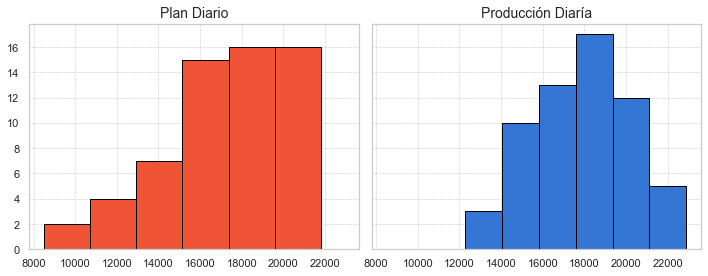

In [290]:

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,4), sharey=True, sharex=True)
#fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2)


ax0.hist(x = df1['PLAN_DIARIO'], bins = 6, histtype='bar', edgecolor='#000000', color='#EE5435')
ax0.set_title('Plan Diario', fontsize=14)
ax0.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.9)

ax1.hist(x = df1['REALIZADO_DIARIO'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax1.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.9)
ax1.set_title('Producción Diaría',fontsize=14)


fig.tight_layout()
plt.show()

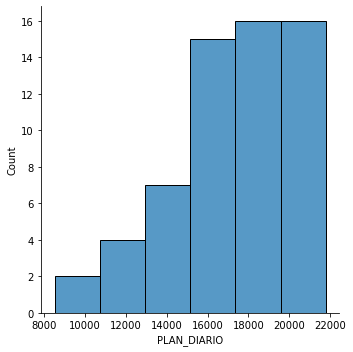

In [141]:
#df1= Plan Diario
sns.displot(df1 , x="PLAN_DIARIO", bins=6)


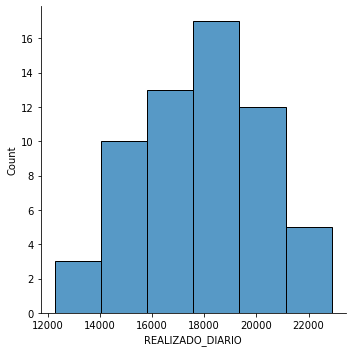

In [142]:
#df1= Produccion diaria
sns.displot(df1 , x="REALIZADO_DIARIO", bins=6)

Analisis datos diarios, graficos Boxplot: generamos dataframe df2df2

In [ ]:
df2 = df.groupby(['FECHA','ZONA','TIPO_LABOR'])[('PLAN_DIARIO','REALIZADO')].sum().reset_index(['FECHA','ZONA','TIPO_LABOR'])
df2 = df1.rename(columns={"REALIZADO": "REALIZADO_DIARIO"})

In [147]:
#Generamos Dataframe df2, para analisis diarios boxplot
df2 = df.groupby(['FECHA','TIPO_LABOR','ZONA'])[('PLAN_DIARIO','REALIZADO')].sum().reset_index(['FECHA','TIPO_LABOR','ZONA'])
df2 = df2.rename(columns={"REALIZADO": "REALIZADO_DIARIO"})
df2.head(4)


,FECHA,TIPO_LABOR,ZONA,PLAN_DIARIO,REALIZADO_DIARIO
0,2020-01-01,Preparación,Zona Alta,0.0,532.544574
1,2020-01-01,Preparación,Zona Baja,0.0,1020.337503
2,2020-01-01,Tajos,Zona Alta,10000.0,7943.416966
3,2020-01-01,Tajos,Zona Baja,8000.0,6390.534889


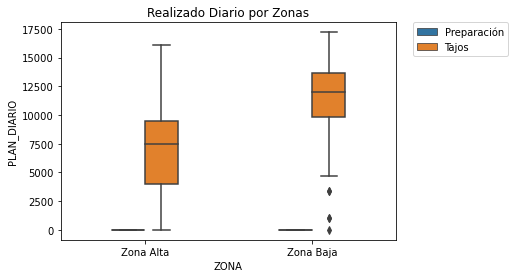

In [149]:
sns.boxplot( x=df2["ZONA"], y=df2["PLAN_DIARIO"], hue=df2["TIPO_LABOR"], width=0.4).set_title('Realizado Diario por Zonas')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

Text(0.5, 1.0, 'Producción Diario')

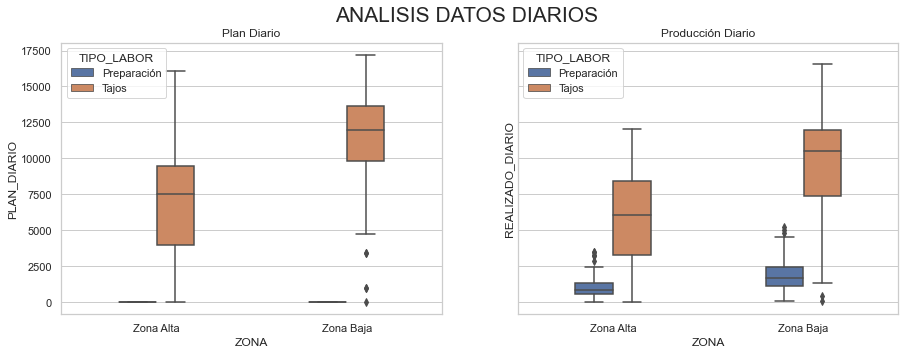

In [207]:
sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)
fig.suptitle('ANALISIS DATOS DIARIOS', fontsize=21)
sns.boxplot( ax=axes[0], x=df2["ZONA"], y=df2["PLAN_DIARIO"], hue=df2["TIPO_LABOR"], width=0.4).set_title('Plan Diario')  
sns.boxplot( ax=axes[1], x=df2["ZONA"], y=df2["REALIZADO_DIARIO"], hue=df2["TIPO_LABOR"], width=0.4).set_title('Producción Diario')


In [ ]:
ANALISIS POR

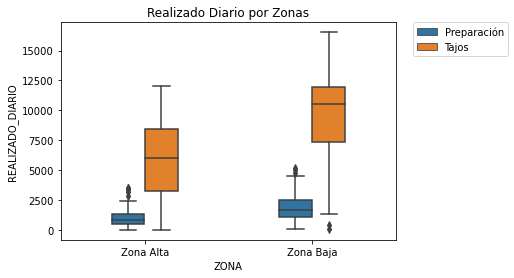

In [148]:
sns.boxplot( x=df2["ZONA"], y=df2["REALIZADO_DIARIO"], hue=df2["TIPO_LABOR"], width=0.4).set_title('Realizado Diario por Zonas')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [42]:
#df2 = produccion turno
df2 = df.groupby(['FECHA','TURNO']).REALIZADO.sum().reset_index(['FECHA','TURNO'])

df5 = df.groupby(['FECHA','TURNO'])[('PLAN_DIARIO','REALIZADO')].sum().reset_index(['FECHA','TURNO'])

df2.head(4)

,FECHA,TURNO,REALIZADO
0,2020-01-01,A,7925.516308
1,2020-01-01,B,7961.317624
2,2020-01-02,A,8543.089008
3,2020-01-02,B,10870.174541


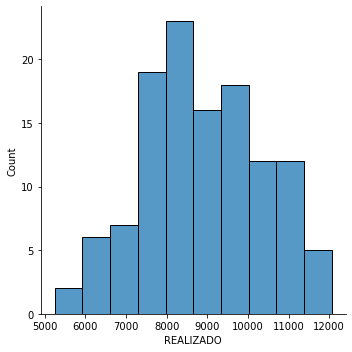

In [41]:
#df2 = produccion turno
sns.displot(df2 , x="REALIZADO", bins=10)

In [13]:
df3 = df.groupby(['FECHA','TURNO']).PLAN_DIARIO.sum().reset_index(['FECHA','TURNO'])
df3.head(4)

,FECHA,TURNO,PLAN_DIARIO
0,2020-01-01,A,9600.0
1,2020-01-01,B,8400.0
2,2020-01-02,A,8400.0
3,2020-01-02,B,9800.0


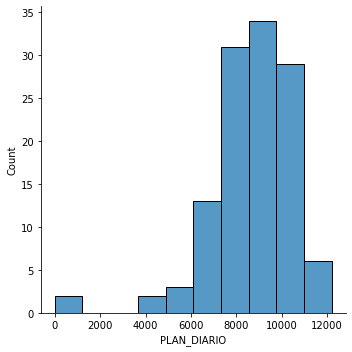

In [14]:
sns.displot(df3 , x="PLAN_DIARIO", bins=10)

In [15]:
df4 = df.groupby('FECHA').PLAN_DIARIO.sum().reset_index('FECHA')
df4.head(4)

,FECHA,PLAN_DIARIO
0,2020-01-01,18000.0
1,2020-01-02,18200.0
2,2020-01-03,20700.0
3,2020-01-04,20000.0


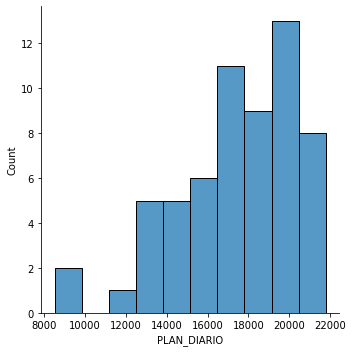

In [16]:
sns.displot(df4 , x="PLAN_DIARIO", bins=10)

In [18]:
df5 = df.groupby(['FECHA','TURNO'])[('PLAN_DIARIO','REALIZADO')].sum().reset_index(['FECHA','TURNO'])
df5.head(4)

,FECHA,TURNO,PLAN_DIARIO,REALIZADO
0,2020-01-01,A,9600.0,7925.516308
1,2020-01-01,B,8400.0,7961.317624
2,2020-01-02,A,8400.0,8543.089008
3,2020-01-02,B,9800.0,10870.174541


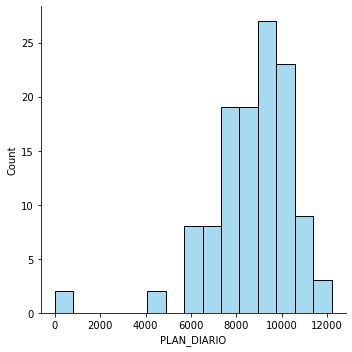

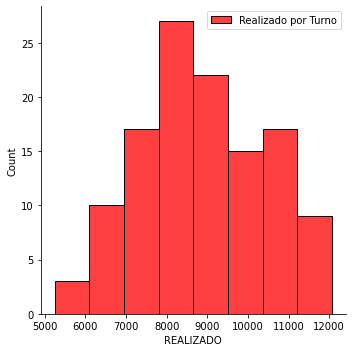

In [19]:
# Method 1: on the same Axis
sns.displot( df5["PLAN_DIARIO"] , color="skyblue", label="Plan Turno Diario")
sns.displot( df5["REALIZADO"] , color="red", label="Realizado por Turno")
plt.legend()

In [29]:
df6= df5[['PLAN_DIARIO','REALIZADO']]
df6.head(3)


,PLAN_DIARIO,REALIZADO
0,9600.0,7925.516308
1,8400.0,7961.317624
2,8400.0,8543.089008


<AxesSubplot:>

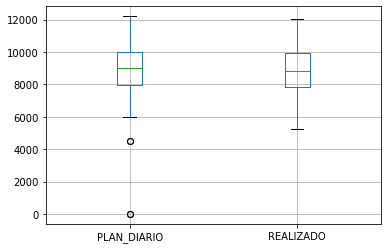

In [33]:
#plt.boxplot(df5["REALIZADO"])
#plt.show()
df5.boxplot(column=['PLAN_DIARIO','REALIZADO'])

<AxesSubplot:xlabel='PLAN_DIARIO', ylabel='Density'>

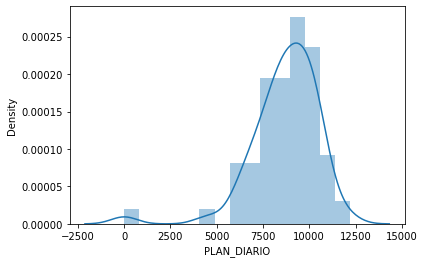

In [133]:
sns.distplot(df5["PLAN_DIARIO"])

<AxesSubplot:xlabel='REALIZADO', ylabel='Density'>

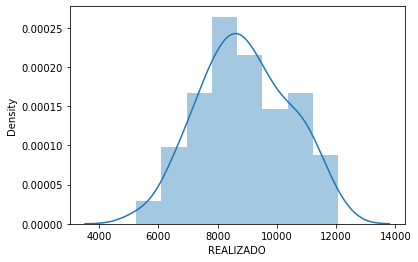

In [134]:
sns.distplot(df5["REALIZADO"])

In [150]:
#Generamos Dataframe df2, para analisis diarios boxplot
df2 = df.groupby(['FECHA','TIPO_LABOR','ZONA'])[('PLAN_DIARIO','REALIZADO')].sum().reset_index(['FECHA','TIPO_LABOR','ZONA'])
df2 = df2.rename(columns={"REALIZADO": "REALIZADO_DIARIO"})
df2.head(4)

,FECHA,TIPO_LABOR,ZONA,PLAN_DIARIO,REALIZADO_DIARIO
0,2020-01-01,Preparación,Zona Alta,0.0,532.544574
1,2020-01-01,Preparación,Zona Baja,0.0,1020.337503
2,2020-01-01,Tajos,Zona Alta,10000.0,7943.416966
3,2020-01-01,Tajos,Zona Baja,8000.0,6390.534889


In [135]:
import math
x1 = 90-(1.64*20/math.sqrt(500))
print (x1) 
x2 = 90+(1.64*20/math.sqrt(500))
print (x2)

88.53313940676014
91.46686059323986


In [159]:
# Random test data
np.random.seed(19680801)
all_data = [np.random.normal(0, std, size=100) for std in range(1, 4)]
labels = ['x1', 'x2', 'x3']
#all_data


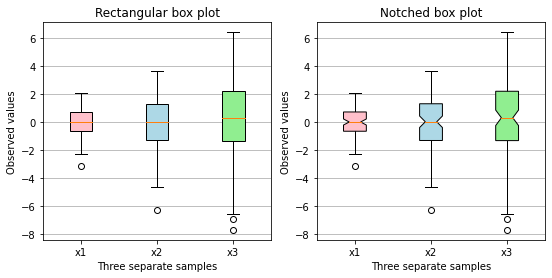

In [156]:
# Plot teh box plots using teh subplot function
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# rectangular box plot
bplot1 = axes[0].boxplot(all_data,
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=labels)  # will be used to label x-ticks
axes[0].set_title('Rectangular box plot')

# notch shape box plot
bplot2 = axes[1].boxplot(all_data,
                         notch=True,  # notch shape
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=labels)  # will be used to label x-ticks
axes[1].set_title('Notched box plot')

# fill with colors
colors = ['pink', 'lightblue', 'lightgreen']
for bplot in (bplot1, bplot2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

# adding horizontal grid lines
for ax in axes:
    ax.yaxis.grid(True)
    ax.set_xlabel('Three separate samples')
    ax.set_ylabel('Observed values')

plt.show()

In [ ]:
# Plot teh box plots using teh subplot function
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# rectangular box plot
bplot1 = axes[0].boxplot(df2, #dataframe
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=labels)  # will be used to label x-ticks
axes[0].set_title('Plan diario')

# notch shape box plot
bplot2 = axes[1].boxplot(df2,
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=labels)  # will be used to label x-ticks
axes[1].set_title('Produccion diaria')

# fill with colors
colors = ['pink', 'lightblue', 'lightgreen']
for bplot in (bplot1, bplot2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

# adding horizontal grid lines
for ax in axes:
    ax.yaxis.grid(True)
    ax.set_xlabel('Three separate samples')
    ax.set_ylabel('Observed values')

plt.show()
